In [1]:
import pandas as ps #importing important libiries for performing the solutions
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=(10,5)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid',palette='rainbow')
%matplotlib inline

#Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.


In [2]:
df = ps.read_csv('/content/exchange_rate.csv', parse_dates=['date'])
display(df.head())

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
df = ps.read_csv('/content/exchange_rate.csv')
display(df.head())
display(df.columns)

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


Index(['date', 'Ex_rate'], dtype='object')

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


None

In [5]:
df = ps.read_csv('/content/exchange_rate.csv', parse_dates=['date'])
df['date'] = ps.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df.set_index('date', inplace=True)
display(df.head())

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [6]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


None

In [7]:
df = ps.read_csv('/content/exchange_rate.csv', parse_dates=['date'])
df['date'] = ps.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df.set_index('date', inplace=True)
display(df.head())

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [8]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


None

In [9]:
upsampled = df.resample('d').asfreq()
upsampled.head(60)

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849
1990-01-06,0.7866
1990-01-07,0.7886
1990-01-08,0.7910
1990-01-09,0.7939


In [10]:
interpolated = upsampled.interpolate()
interpolated.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


<Axes: xlabel='date'>

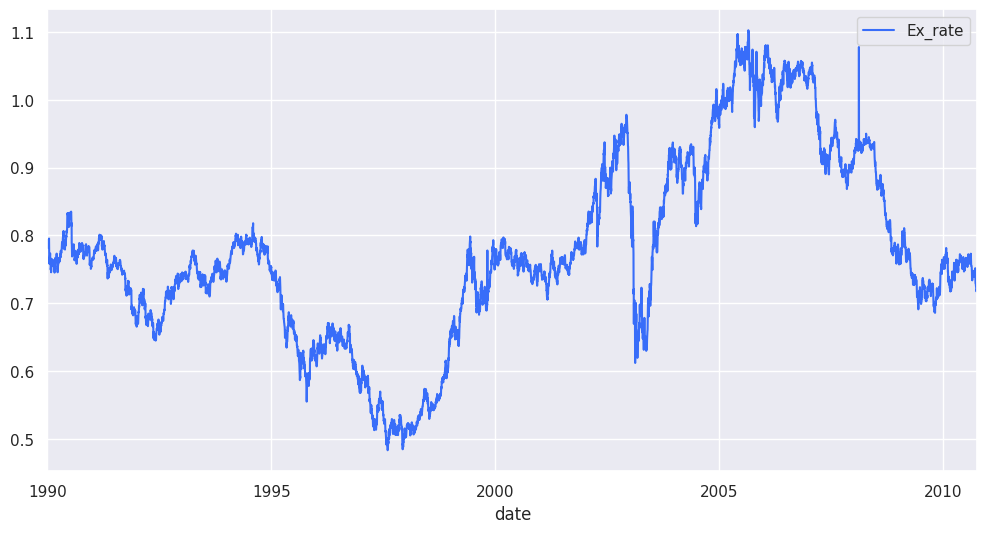

In [11]:
interpolated.plot(figsize=(12,6))

In [12]:
downsampled=df.resample('q').mean()
downsampled

,Ex_rate
date,
1990-03-31,0.764122
1990-06-30,0.792053
1990-09-30,0.785475
1990-12-31,0.774154
1991-03-31,0.783332
...,...
2009-12-31,0.719797
2010-03-31,0.746596
2010-06-30,0.755990


In [13]:
downsampled.shape


(84, 1)

<Axes: xlabel='date'>

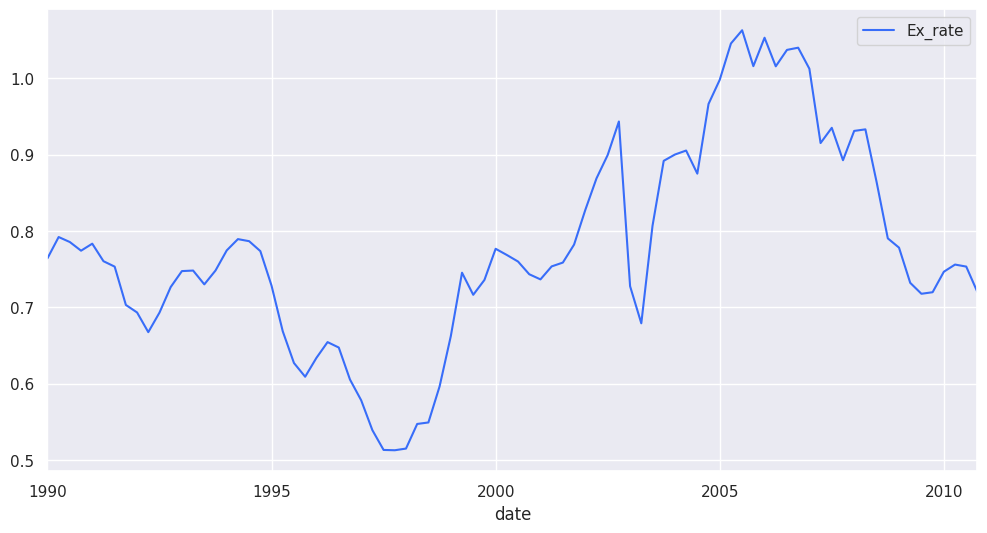

In [14]:
downsampled.plot(figsize=(12,6))

#Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


In [16]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.9 MB/s eta 0:00:00


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller #it chiecks if dat is stationary or nonstationary
from pmdarima import auto_arima #it will get order for (p,d,q)
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import  mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [32]:
df.dropna(inplace=True)

In [33]:
df

,Ex_rate
date,
1990-01-01,0.785500
1990-01-02,0.781800
1990-01-03,0.786700
1990-01-04,0.786000
1990-01-05,0.784900
...,...
2010-10-06,0.718494
2010-10-07,0.721839
2010-10-08,0.723197


<Axes: xlabel='date'>

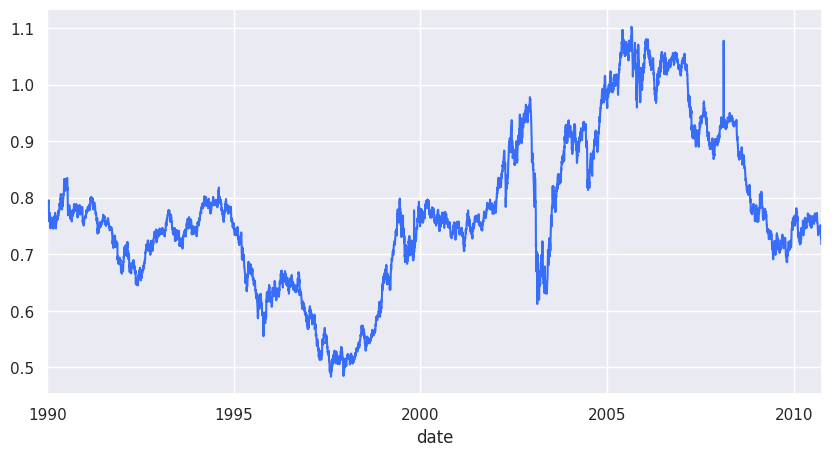

In [34]:
df['Ex_rate'].plot(figsize=(10,5))

In [35]:
dftest=adfuller(df['Ex_rate'])
print("p value:",dftest[1])

p value: 0.4492327353597477


Here p value is under less then 0.05 so data is staionary.

*ARIMA Model building

In [36]:
stepwise_fit=auto_arima(df['Ex_rate'],trace=True,suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-56098.154, Time=3.29 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-55972.211, Time=1.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-56102.338, Time=0.56 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-56100.772, Time=4.38 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-55974.195, Time=0.32 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-56100.340, Time=3.57 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-56100.341, Time=2.52 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-56098.328, Time=4.92 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-56104.319, Time=0.35 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-56102.321, Time=0.57 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-56102.322, Time=1.53 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-56102.753, Time=0.90 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-56100.315, Time=3.58 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 27.658 sec

We get the value of Auto regression(p),Integraded(d),Moving avg.(q).
Akaike"s information criterion (AIC),which was usefull in selections for regression,it is also useful for determining the order of an ARIMA model.
Lesser AIC better model.

In [37]:
#creating ARIMA mode
#spliting the data

train=df.iloc[:-30]
test=df.iloc[-30:]
print (train.shape,test.shape)

(7558, 1) (30, 1)


Evaluation the model

In [38]:
model=ARIMA(train['Ex_rate'],order=(1,1,0))
model=model.fit()


In [41]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 7558
Model:                 ARIMA(1, 1, 0)   Log Likelihood               27934.469
Date:                Thu, 09 Apr 2026   AIC                         -55864.938
Time:                        13:03:06   BIC                         -55851.078
Sample:                    01-01-1990   HQIC                        -55860.180
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1317      0.002    -64.444      0.000      -0.136      -0.128
sigma2      3.604e-05   9.99e-08    360.870      0.000    3.58e-05    3.62e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2846350.67
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               2.98   Skew:                             0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                        98.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [42]:
test

,Ex_rate
date,
2010-09-11,0.745796
2010-09-12,0.745045
2010-09-13,0.747692
2010-09-14,0.745601
2010-09-15,0.747680
2010-09-16,0.744602
2010-09-17,0.744158
2010-09-18,0.745184
2010-09-19,0.744990


In [46]:
pred=model.predict(start=7558,end=7587)

as  sequenstial data we have the give the date

In [47]:
index_future_dates=pd.date_range(start='2010-09-11',end='2010-10-10')
pred.index=index_future_dates
display(pred.head())

,predicted_mean
2010-09-11,0.744095
2010-09-12,0.744155
2010-09-13,0.744147
2010-09-14,0.744148
2010-09-15,0.744148


In [49]:
from math import sqrt
test['Ex_rate'].mean()
rsme=sqrt(mean_squared_error(pred,test['Ex_rate']))
print(rsme)

0.0166346976048715


since there is less error so it is a good model

### Diagnostics: Analyze Residuals

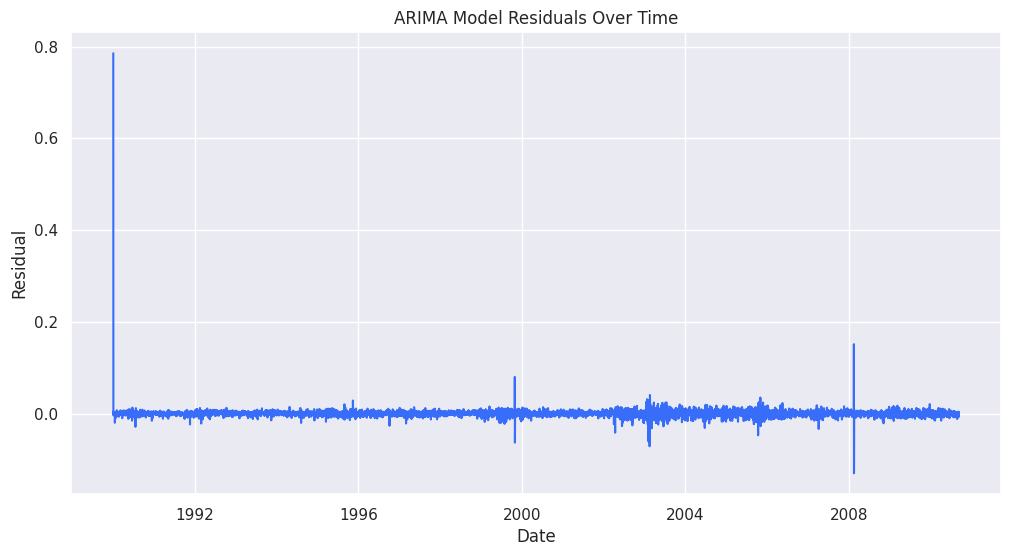

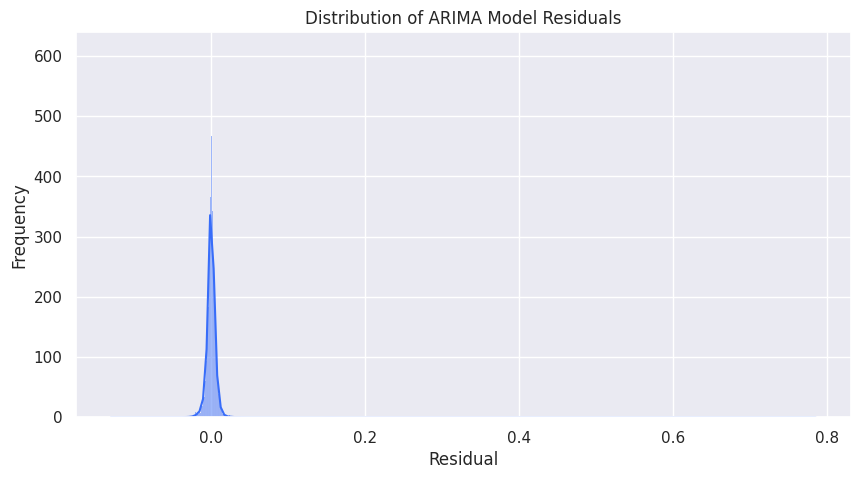

In [50]:
residuals = model.resid

plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('ARIMA Model Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

sns.histplot(residuals, kde=True)
plt.title('Distribution of ARIMA Model Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

### Forecasting: Visualize Predicted vs. Actual Values

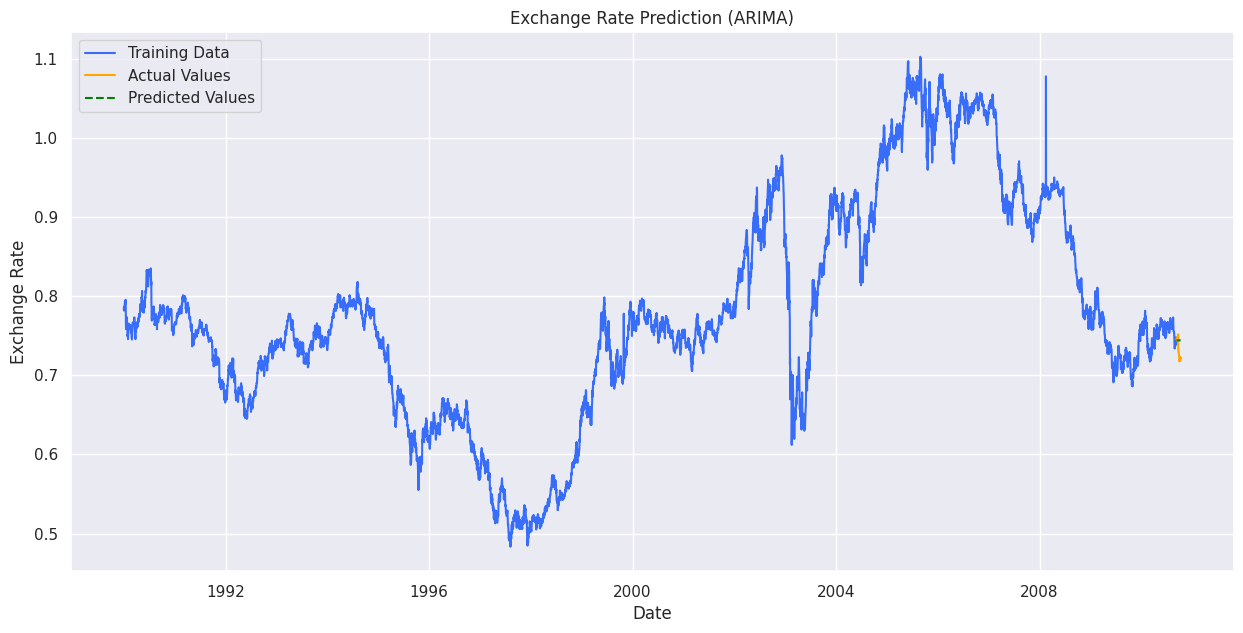

In [51]:
plt.figure(figsize=(15, 7))
plt.plot(train['Ex_rate'].index, train['Ex_rate'], label='Training Data')
plt.plot(test['Ex_rate'].index, test['Ex_rate'], label='Actual Values', color='orange')
plt.plot(pred.index, pred, label='Predicted Values', color='green', linestyle='--')
plt.title('Exchange Rate Prediction (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

#Part 3: Model Building - Exponential Smoothing
1.	Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).
2.	Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.
3.	Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.


### Part 3: Model Building - Exponential Smoothing

In [52]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Model Selection and Parameter Optimization
# Using Holt-Winters (Triple Exponential Smoothing) due to potential trend and seasonality
# We'll let statsmodels optimize the parameters (smoothing levels for level, trend, and seasonal components)
# Since daily data might have weekly seasonality, we'll try a seasonal period of 7.
# We need to ensure the series has a frequency specified for seasonal models.

df_freq = df.asfreq('D') # Ensure daily frequency

# Re-split the data with the new frequency-aware dataframe
train_exp_smoothing = df_freq.iloc[:-30]
test_exp_smoothing = df_freq.iloc[-30:]

# Fit the Holt-Winters model
# Assuming additive trend and seasonal components for now, can be changed to 'multiplicative' if needed
hw_model = ExponentialSmoothing(train_exp_smoothing['Ex_rate'],
                                trend='add',
                                seasonal='add',
                                seasonal_periods=7).fit()

display(hw_model.summary())

Dep. Variable:,Ex_rate,No. Observations:,7558
Model:,ExponentialSmoothing,SSE,0.272
Optimized:,True,AIC,-77306.595
Trend:,Additive,BIC,-77230.361
Seasonal:,Additive,AICC,-77306.547
Seasonal Periods:,7,Date:,"Thu, 09 Apr 2026"
Box-Cox:,False,Time:,13:19:12
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.8696564,alpha,True
smoothing_trend,0.000000,beta,True


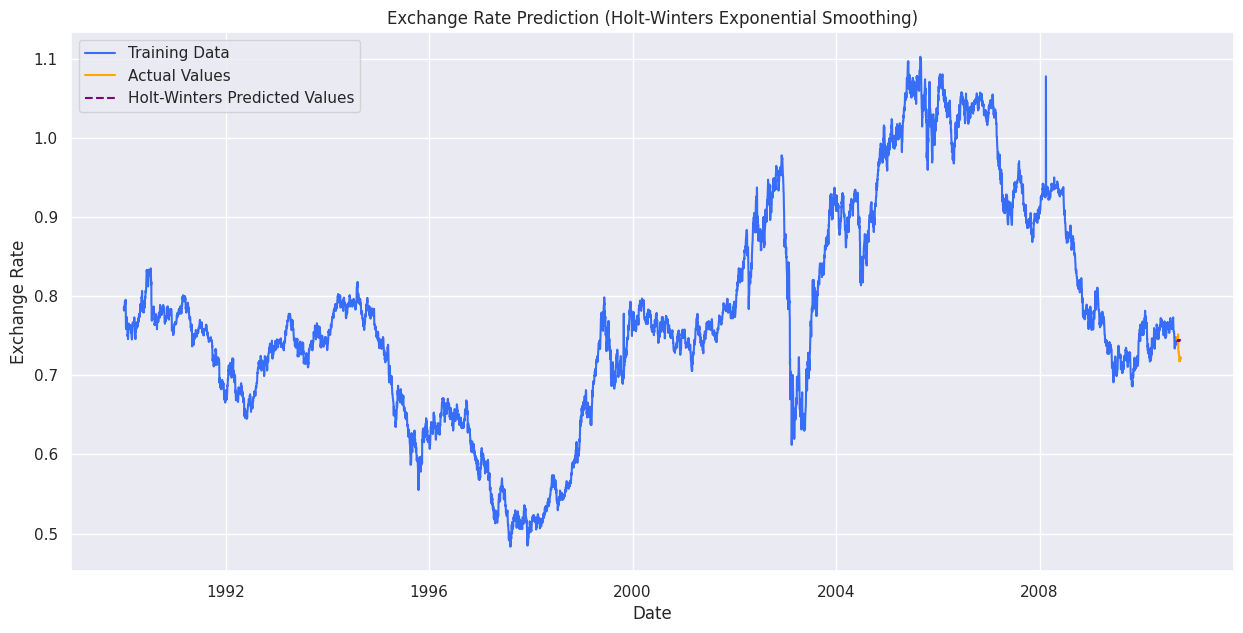

RMSE for Holt-Winters model: 0.016466836913411283


In [53]:
# Forecasting
hw_predictions = hw_model.predict(start=len(train_exp_smoothing), end=len(df_freq)-1)

# Visualize the predicted values against the actual values
plt.figure(figsize=(15, 7))
plt.plot(train_exp_smoothing['Ex_rate'].index, train_exp_smoothing['Ex_rate'], label='Training Data')
plt.plot(test_exp_smoothing['Ex_rate'].index, test_exp_smoothing['Ex_rate'], label='Actual Values', color='orange')
plt.plot(hw_predictions.index, hw_predictions, label='Holt-Winters Predicted Values', color='purple', linestyle='--')
plt.title('Exchange Rate Prediction (Holt-Winters Exponential Smoothing)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the model (e.g., using RMSE)
rmse_hw = sqrt(mean_squared_error(hw_predictions, test_exp_smoothing['Ex_rate']))
print(f'RMSE for Holt-Winters model: {rmse_hw}')

#Part 4: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


In [55]:
from sklearn.metrics import mean_absolute_error

# ARIMA Model Evaluation
mae_arima = mean_absolute_error(test['Ex_rate'], pred)
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape_arima = mape(test['Ex_rate'], pred)

# Holt-Winters Model Evaluation
mae_hw = mean_absolute_error(test_exp_smoothing['Ex_rate'], hw_predictions)
mape_hw = mape(test_exp_smoothing['Ex_rate'], hw_predictions)

print('ARIMA Model Metrics:')
print(f'RMSE: {rsme:.4f}')
print(f'MAE: {mae_arima:.4f}')
print(f'MAPE: {mape_arima:.4f}%')
print('\nHolt-Winters Model Metrics:')
print(f'RMSE: {rmse_hw:.4f}')
print(f'MAE: {mae_hw:.4f}')
print(f'MAPE: {mape_hw:.4f}%')

ARIMA Model Metrics:
RMSE: 0.0166
MAE: 0.0135
MAPE: 1.8633%

Holt-Winters Model Metrics:
RMSE: 0.0165
MAE: 0.0134
MAPE: 1.8515%


### Part 4: Evaluation and Comparison

Now we will compare the performance of the ARIMA and Holt-Winters models using RMSE, MAE, and MAPE. Based on these metrics, we will discuss their advantages and limitations and conclude which model performs better for this dataset.

### Model Comparison

1. Root Mean Squared Error (RMSE):
   - ARIMA: 0.0166
   - Holt-Winters: 0.0165
   *Interpretation:* RMSE gives a relatively high weight to large errors. A lower RMSE indicates a better fit. In this case, both models have very similar RMSE values, with Holt-Winters slightly lower.

2. Mean Absolute Error (MAE):
   - ARIMA: 0.0135
   - Holt-Winters: 0.0134
   Interpretation: MAE measures the average magnitude of the errors without considering their direction. It is robust to outliers. Again, Holt-Winters shows a marginally better (lower) MAE.

3. Mean Absolute Percentage Error (MAPE):
   - ARIMA: 1.8633%
   - Holt-Winters: 1.8515%
   Interpretation: MAPE expresses the error as a percentage, which is often easier to understand. A lower MAPE is better. Holt-Winters has a slightly lower MAPE, suggesting better percentage accuracy.

### Discussion:

* Performance: Both models perform quite similarly on this dataset for the given forecast horizon of 30 days. However, the Holt-Winters model consistently shows slightly better performance across all three metrics (RMSE, MAE, MAPE), indicating slightly more accurate predictions.

* ARIMA Advantages/Limitations:
    * Advantages: Good for capturing complex dependencies and can model non-stationary data through differencing. auto_arima helps in parameter selection.
    * Limitations: Can be sensitive to outliers and requires stationarity (or differencing to achieve it). Interpreting parameters can be complex. In this case, it might be slightly over-fitting or less effective at capturing the specific short-term patterns that Holt-Winters might be picking up.

* Holt-Winters Advantages/Limitations:
    * Advantages: Excellent for time series with clear trend and seasonality. Relatively intuitive to understand the components (level, trend, seasonality). Often performs well for short-to-medium term forecasts.
    * Limitations:Requires specifying the type of trend and seasonality (additive/multiplicative) and the seasonal period. Can struggle with highly irregular patterns or very long forecast horizons if the trend/seasonal components change drastically.

### Conclusion:

For forecasting the exchange rates in this dataset, the **Holt-Winters Exponential Smoothing model appears to be marginally better** than the ARIMA model, as indicated by its slightly lower RMSE, MAE, and MAPE. This suggests that the trend and seasonal components are well-captured by the Holt-Winters model, leading to slightly more accurate short-term predictions. Both models demonstrate good performance with relatively low error rates, indicating they are suitable for this forecasting task.